In [57]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report

# Loading the dataset

In [58]:
credit_df = pd.read_csv("german_credit_data.csv")
print(credit_df)

     Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0     67    male    2     own             NaN           little           1169   
1     22  female    2     own          little         moderate           5951   
2     49    male    1     own          little              NaN           2096   
3     45    male    2    free          little           little           7882   
4     53    male    2    free          little           little           4870   
..   ...     ...  ...     ...             ...              ...            ...   
995   31  female    1     own          little              NaN           1736   
996   40    male    3     own          little           little           3857   
997   38    male    2     own          little              NaN            804   
998   23    male    2    free          little           little           1845   
999   27    male    2     own        moderate         moderate           4576   

     Duration              

# Filling in the missing values

In [59]:
credit_df["Checking account"] = credit_df["Checking account"].fillna('none')
credit_df["Saving accounts"] = credit_df["Saving accounts"].fillna('none')
print(credit_df.head(10))

   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own            none           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little             none           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   
5   35    male    1    free            none             none           9055   
6   53    male    2     own      quite rich             none           2835   
7   35    male    3    rent          little         moderate           6948   
8   61    male    1     own            rich             none           3059   
9   28    male    3     own          little         moderate           5234   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        48             radio/TV   bad  
2      

# Using label encoding to encode the categorical target variable `risk`

In [60]:
label_enc = LabelEncoder()
credit_df["Risk"] = label_enc.fit_transform(credit_df["Risk"])
print(credit_df["Risk"])
encoded_results = dict(zip(label_enc.classes_,label_enc.transform(label_enc.classes_)))
print(encoded_results)

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64
{'bad': np.int64(0), 'good': np.int64(1)}


# Dropping the redundant sex feature

In [61]:
print(credit_df.columns)
# new_credit_df = credit_df.drop(columns=["Sex"])
# print(new_credit_df.columns)

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


# Performing one hot encoding on the features

In [62]:
X = credit_df.drop("Risk",axis=1)
one_hot_enc = OneHotEncoder()
encoded_features = one_hot_enc.fit_transform(X)
# print(encoded_features)
dense_features = encoded_features.toarray()

print(dense_features)
feature_names = one_hot_enc.get_feature_names_out(input_features=X.columns)
df_encoded = pd.DataFrame(dense_features,columns=feature_names)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [63]:
scaler = StandardScaler()

In [64]:
non_numeric_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
columns_to_drop = ["Risk"]
X_encoded = pd.get_dummies(credit_df.drop(columns=[c for c in columns_to_drop if c in credit_df.columns],axis=1),columns=non_numeric_cols,drop_first=True)
print(X_encoded.dtypes.value_counts())
y = credit_df["Risk"]
X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=42)
print(X_encoded.select_dtypes(exclude=["number"]).columns)

print(X_encoded)

bool     17
int64     4
Name: count, dtype: int64
Index(['Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate',
       'Saving accounts_none', 'Saving accounts_quite rich',
       'Saving accounts_rich', 'Checking account_moderate',
       'Checking account_none', 'Checking account_rich', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='object')
     Age  Job  Credit amount  Duration  Sex_male  Housing_own  Housing_rent  \
0     67    2           1169         6      True         True         False   
1     22    2           5951        48     False         True         False   
2     49    1           2096        12      True         True         False   
3     45    2           7882        42      True        False         False   
4     53    2           4870        24      True        False         False   
..   ...  ..

In [65]:
print(X_train.select_dtypes(include=["number"]).columns)
print(X_train.select_dtypes(exclude=["number"]).columns)

Index(['Age', 'Job', 'Credit amount', 'Duration'], dtype='object')
Index(['Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate',
       'Saving accounts_none', 'Saving accounts_quite rich',
       'Saving accounts_rich', 'Checking account_moderate',
       'Checking account_none', 'Checking account_rich', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='object')


In [66]:
numerical_cols = ['Age', 'Job', 'Credit amount', 'Duration']
features_final = numerical_cols + [c for c in X_encoded.columns if c not in numerical_cols]
print(features_final)
n = len(features_final)
print("There are",n,"features in the dataset")

['Age', 'Job', 'Credit amount', 'Duration', 'Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_none', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_none', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']
There are 21 features in the dataset


In [67]:
X_train = X_train[features_final]
X_test = X_test[features_final]


# Scaling the dataset

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Finding out the optimal `k` for KNN

In [69]:
train_scores = []
k_values = range(1,11)
cv_scores_mean = []

for k in k_values:
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_train_scaled,y_train)

    train_scores.append(knn_clf.score(X_train_scaled,y_train))
    cv_scores = cross_val_score(knn_clf,X_train_scaled,y_train,scoring="accuracy")
    cv_scores_mean.append(cv_scores.mean())

print(cv_scores_mean)
print(train_scores)

[np.float64(0.6624999999999999), np.float64(0.60125), np.float64(0.6900000000000001), np.float64(0.655), np.float64(0.6987500000000001), np.float64(0.69625), np.float64(0.7125000000000001), np.float64(0.69375), np.float64(0.7037500000000001), np.float64(0.6925)]
[1.0, 0.82125, 0.815, 0.7925, 0.7925, 0.7825, 0.7825, 0.77375, 0.77375, 0.7625]


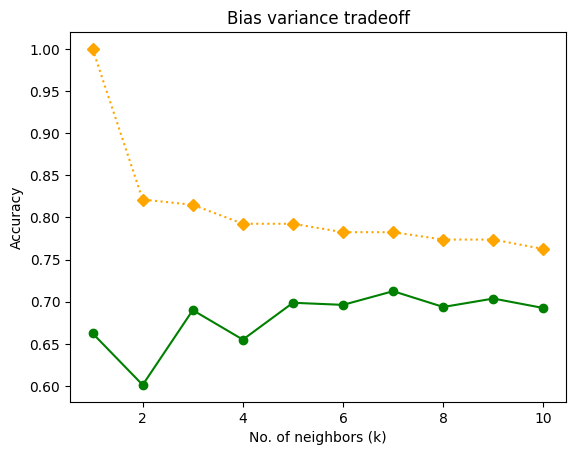

In [70]:
plt.plot(k_values,cv_scores_mean,marker="o",label="Cross Validation Accuracy (Variance indicator)",color="green")
plt.plot(k_values,train_scores,marker="D",linestyle="dotted",label="Training Accuracy (Bias indicator)",color="orange")
plt.xlabel("No. of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Bias variance tradeoff")
plt.show()

In [71]:
optimal_k = k_values[np.argmax(cv_scores_mean)]
optimized_knn = KNeighborsClassifier(n_neighbors=optimal_k,metric="euclidean",weights="distance")
optimized_knn.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [77]:
y_pred = optimized_knn.predict(X_test_scaled)
print(y_pred)


[1 1 1 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 1 1 0 1 1 0
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1
 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1]


# Evaluating the model

In [73]:
conf_mat = confusion_matrix(y_test,y_pred)
print(conf_mat)

[[ 19  40]
 [ 16 125]]


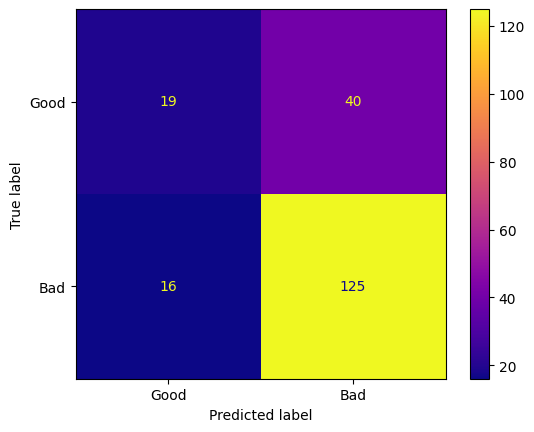

In [74]:
disp = ConfusionMatrixDisplay(conf_mat,display_labels=["Good","Bad"])
disp.plot(cmap=plt.cm.plasma)
plt.show()

In [75]:
print("Classification report: \n",classification_report(y_test,y_pred))

Classification report: 
               precision    recall  f1-score   support

           0       0.54      0.32      0.40        59
           1       0.76      0.89      0.82       141

    accuracy                           0.72       200
   macro avg       0.65      0.60      0.61       200
weighted avg       0.69      0.72      0.70       200

